<a href="https://colab.research.google.com/github/Tamaranimi/COSC-698---Applied-Research/blob/main/COSC_698_Proposed_Stability_Guided_Multi_Start_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

           Dataset                                 Method  WCSS_mean  \
0  Synthetic Blobs                  Random Initialization  3668.8159   
1  Synthetic Blobs                              K-means++  1946.9121   
2  Synthetic Blobs  Proposed Stability-Guided Multi-Start  1663.1908   
3             Iris                  Random Initialization   162.7027   
4             Iris                              K-means++   145.7238   
5             Iris  Proposed Stability-Guided Multi-Start   140.1739   
6             Wine                  Random Initialization  1278.9560   
7             Wine                              K-means++  1278.3819   
8             Wine  Proposed Stability-Guided Multi-Start  1277.9285   

   Silhouette_mean  DB_mean  Runtime_mean  Iterations_mean  Stability_ARI  
0           0.6976   0.4546        0.0045              6.9         0.7859  
1           0.7305   0.4011        0.0076              2.9         0.9260  
2           0.7458   0.3592        0.0764          

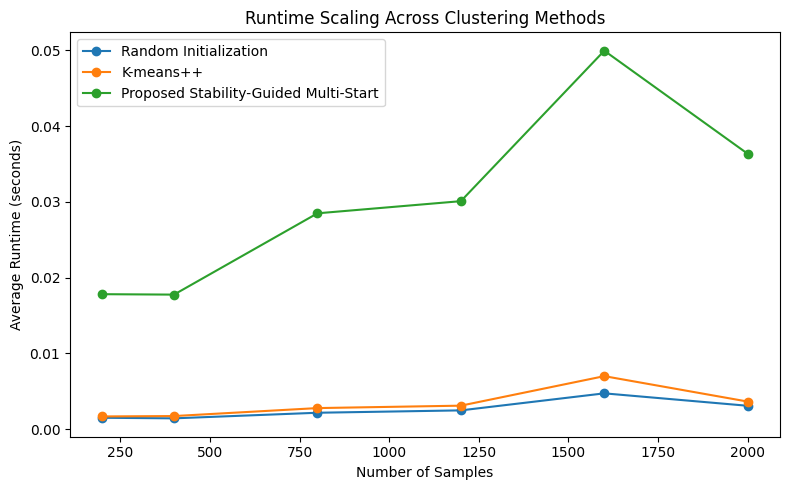

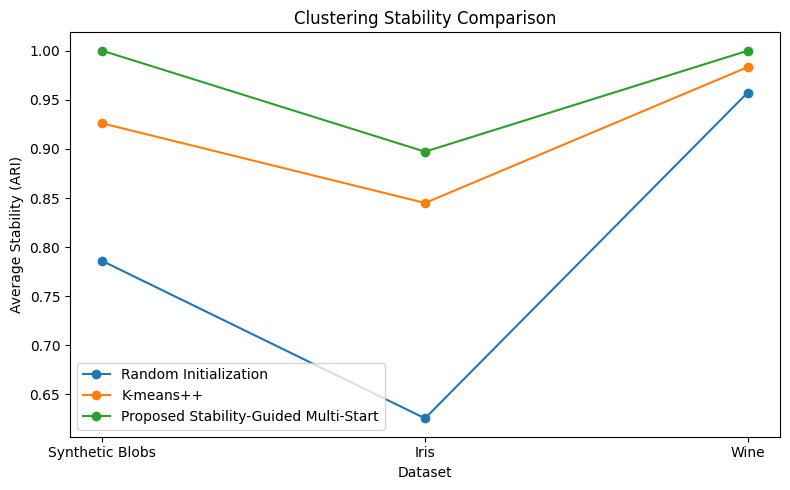

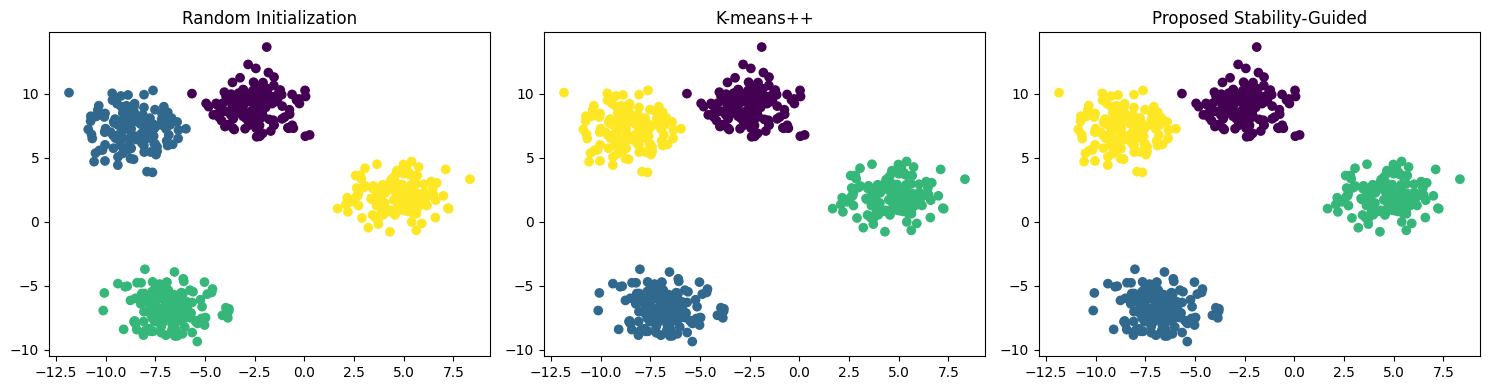

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, load_iris, load_wine
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler


# -----------------------------
# Utility functions
# -----------------------------
def evaluate_single_run(X, k, init_method, random_state):
    start = time.time()

    km = KMeans(
        n_clusters=k,
        init=init_method,
        n_init=1,
        random_state=random_state,
        max_iter=300
    )
    labels = km.fit_predict(X)

    runtime = time.time() - start
    inertia = km.inertia_
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    iters = km.n_iter_

    return {
        "labels": labels,
        "inertia": inertia,
        "silhouette": sil,
        "davies_bouldin": db,
        "runtime": runtime,
        "iterations": iters
    }


def pairwise_stability(labels_list):
    """Average ARI across all pairs of clustering runs."""
    aris = []
    for i in range(len(labels_list)):
        for j in range(i + 1, len(labels_list)):
            aris.append(adjusted_rand_score(labels_list[i], labels_list[j]))
    return np.mean(aris) if aris else 1.0


def normalize_scores(values, higher_is_better=True):
    values = np.array(values, dtype=float)
    if np.allclose(values.max(), values.min()):
        return np.ones_like(values)
    norm = (values - values.min()) / (values.max() - values.min())
    return norm if higher_is_better else 1 - norm


def stability_guided_multistart(X, k, R=10, lambda_weight=0.5, base_seed=42):
    runs = []
    for r in range(R):
        res = evaluate_single_run(X, k, init_method="k-means++", random_state=base_seed + r)
        runs.append(res)

    labels_list = [r["labels"] for r in runs]

    # Compute stability contribution for each run
    stability_scores = []
    for i in range(R):
        scores = []
        for j in range(R):
            if i != j:
                scores.append(adjusted_rand_score(labels_list[i], labels_list[j]))
        stability_scores.append(np.mean(scores))

    # Normalize quality metrics
    inertia_vals = [r["inertia"] for r in runs]
    sil_vals = [r["silhouette"] for r in runs]
    db_vals = [r["davies_bouldin"] for r in runs]

    inertia_norm = normalize_scores(inertia_vals, higher_is_better=False)
    sil_norm = normalize_scores(sil_vals, higher_is_better=True)
    db_norm = normalize_scores(db_vals, higher_is_better=False)
    stab_norm = normalize_scores(stability_scores, higher_is_better=True)

    # Combined quality score
    quality_scores = (inertia_norm + sil_norm + db_norm) / 3.0

    composite_scores = lambda_weight * quality_scores + (1 - lambda_weight) * stab_norm
    best_idx = int(np.argmax(composite_scores))
    best_run = runs[best_idx]

    total_runtime = sum(r["runtime"] for r in runs)

    return {
        "labels": best_run["labels"],
        "inertia": best_run["inertia"],
        "silhouette": best_run["silhouette"],
        "davies_bouldin": best_run["davies_bouldin"],
        "runtime": total_runtime,
        "iterations": best_run["iterations"],
        "stability": np.mean(stability_scores),
        "best_run_index": best_idx,
        "all_runs": runs
    }


def evaluate_method_multiple_runs(X, k, method_name, outer_runs=10, seed_start=100):
    results = []

    if method_name == "Random":
        init_method = "random"
        for i in range(outer_runs):
            res = evaluate_single_run(X, k, init_method=init_method, random_state=seed_start + i)
            results.append(res)

        stability = pairwise_stability([r["labels"] for r in results])

        return {
            "Method": "Random Initialization",
            "WCSS_mean": np.mean([r["inertia"] for r in results]),
            "Silhouette_mean": np.mean([r["silhouette"] for r in results]),
            "DB_mean": np.mean([r["davies_bouldin"] for r in results]),
            "Runtime_mean": np.mean([r["runtime"] for r in results]),
            "Iterations_mean": np.mean([r["iterations"] for r in results]),
            "Stability_ARI": stability
        }

    elif method_name == "KMeans++":
        init_method = "k-means++"
        for i in range(outer_runs):
            res = evaluate_single_run(X, k, init_method=init_method, random_state=seed_start + i)
            results.append(res)

        stability = pairwise_stability([r["labels"] for r in results])

        return {
            "Method": "K-means++",
            "WCSS_mean": np.mean([r["inertia"] for r in results]),
            "Silhouette_mean": np.mean([r["silhouette"] for r in results]),
            "DB_mean": np.mean([r["davies_bouldin"] for r in results]),
            "Runtime_mean": np.mean([r["runtime"] for r in results]),
            "Iterations_mean": np.mean([r["iterations"] for r in results]),
            "Stability_ARI": stability
        }

    elif method_name == "Proposed":
        outer = []
        for i in range(outer_runs):
            res = stability_guided_multistart(X, k, R=10, lambda_weight=0.5, base_seed=seed_start + i * 20)
            outer.append(res)

        stability = pairwise_stability([r["labels"] for r in outer])

        return {
            "Method": "Proposed Stability-Guided Multi-Start",
            "WCSS_mean": np.mean([r["inertia"] for r in outer]),
            "Silhouette_mean": np.mean([r["silhouette"] for r in outer]),
            "DB_mean": np.mean([r["davies_bouldin"] for r in outer]),
            "Runtime_mean": np.mean([r["runtime"] for r in outer]),
            "Iterations_mean": np.mean([r["iterations"] for r in outer]),
            "Stability_ARI": stability
        }

    else:
        raise ValueError("Unknown method")


# -----------------------------
# Dataset preparation
# -----------------------------
# Synthetic dataset
X_syn, y_syn = make_blobs(
    n_samples=600,
    centers=4,
    cluster_std=1.2,
    n_features=2,
    random_state=42
)

# Benchmark dataset: Iris
iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)

# Benchmark dataset: Wine
wine = load_wine()
X_wine = StandardScaler().fit_transform(wine.data)


# -----------------------------
# Run experiments
# -----------------------------
def compare_methods(X, k, dataset_name):
    rows = []
    for method in ["Random", "KMeans++", "Proposed"]:
        rows.append(evaluate_method_multiple_runs(X, k, method_name=method, outer_runs=10))

    df = pd.DataFrame(rows)
    df.insert(0, "Dataset", dataset_name)
    return df


df_syn = compare_methods(X_syn, k=4, dataset_name="Synthetic Blobs")
df_iris = compare_methods(X_iris, k=3, dataset_name="Iris")
df_wine = compare_methods(X_wine, k=3, dataset_name="Wine")

results_df = pd.concat([df_syn, df_iris, df_wine], ignore_index=True)
print(results_df.round(4))

# Save table for paper
results_df.round(4).to_csv("clustering_results_table.csv", index=False)


# -----------------------------
# Runtime scaling experiment
# -----------------------------
sizes = [200, 400, 800, 1200, 1600, 2000]
runtime_records = []

for n in sizes:
    X_tmp, _ = make_blobs(
        n_samples=n,
        centers=4,
        cluster_std=1.2,
        n_features=2,
        random_state=42
    )

    rand_row = evaluate_method_multiple_runs(X_tmp, k=4, method_name="Random", outer_runs=5)
    plus_row = evaluate_method_multiple_runs(X_tmp, k=4, method_name="KMeans++", outer_runs=5)
    prop_row = evaluate_method_multiple_runs(X_tmp, k=4, method_name="Proposed", outer_runs=5)

    runtime_records.append({
        "n_samples": n,
        "Method": "Random Initialization",
        "Runtime_mean": rand_row["Runtime_mean"]
    })
    runtime_records.append({
        "n_samples": n,
        "Method": "K-means++",
        "Runtime_mean": plus_row["Runtime_mean"]
    })
    runtime_records.append({
        "n_samples": n,
        "Method": "Proposed Stability-Guided Multi-Start",
        "Runtime_mean": prop_row["Runtime_mean"]
    })

runtime_df = pd.DataFrame(runtime_records)
runtime_df.to_csv("runtime_scaling_results.csv", index=False)


# -----------------------------
# Plot 1: Runtime scaling
# -----------------------------
plt.figure(figsize=(8, 5))
for method in runtime_df["Method"].unique():
    subset = runtime_df[runtime_df["Method"] == method]
    plt.plot(subset["n_samples"], subset["Runtime_mean"], marker="o", label=method)

plt.xlabel("Number of Samples")
plt.ylabel("Average Runtime (seconds)")
plt.title("Runtime Scaling Across Clustering Methods")
plt.legend()
plt.tight_layout()
plt.savefig("runtime_scaling_plot.png", dpi=300)
plt.show()


# -----------------------------
# Plot 2: Stability comparison
# -----------------------------
plot_df = results_df.copy()

plt.figure(figsize=(8, 5))
for method in plot_df["Method"].unique():
    subset = plot_df[plot_df["Method"] == method]
    plt.plot(subset["Dataset"], subset["Stability_ARI"], marker="o", label=method)

plt.xlabel("Dataset")
plt.ylabel("Average Stability (ARI)")
plt.title("Clustering Stability Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("stability_comparison_plot.png", dpi=300)
plt.show()


# -----------------------------
# Plot 3: Cluster Visualization
# -----------------------------
X_vis, _ = make_blobs(
    n_samples=600,
    centers=4,
    cluster_std=1.2,
    random_state=42
)

k = 4

# Random initialization
k_random = KMeans(n_clusters=k, init="random", n_init=10, random_state=42)
labels_random = k_random.fit_predict(X_vis)

# K-means++
k_plus = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
labels_plus = k_plus.fit_predict(X_vis)

# Proposed stability-guided method
prop_result = stability_guided_multistart(X_vis, k=4, R=10, lambda_weight=0.5, base_seed=42)
labels_prop = prop_result["labels"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(X_vis[:, 0], X_vis[:, 1], c=labels_random)
axes[0].set_title("Random Initialization")

axes[1].scatter(X_vis[:, 0], X_vis[:, 1], c=labels_plus)
axes[1].set_title("K-means++")

axes[2].scatter(X_vis[:, 0], X_vis[:, 1], c=labels_prop)
axes[2].set_title("Proposed Stability-Guided")

plt.tight_layout()
plt.savefig("cluster_visualization.png", dpi=300)
plt.show()